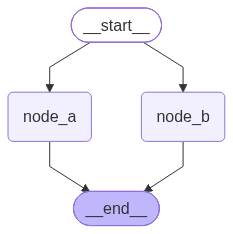

============================== -> interrupt_res <- ==============================
{'age': 12, '__interrupt__': [Interrupt(value='请输入您的姓名', id='ad476ad7c995a614d202ea6df33d5f3c')]}
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	__start__ --> node_b;
	node_a --> __end__;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from typing import TypedDict


from langgraph.graph import StateGraph, START, END
from langgraph.types import Command,interrupt
from langgraph.checkpoint.memory import InMemorySaver

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) -> OverAllState:
    age = 12
    return {
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

list(graph.get_state_history(config=config))
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

In [3]:
res = graph.invoke(Command(resume="小黄"), config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(res)

list(graph.get_state_history(config=config))

============================== -> interrupt_res <- ==============================
{'username': '小黄', 'age': 12}


[StateSnapshot(values={'username': '小黄', 'age': 12}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4eb-74db-6264-8001-f75620e88fc3'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-10T11:01:34.981169+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4e9-b24c-6381-8000-67271db66fec'}}, tasks=(), interrupts=()),
 StateSnapshot(values={}, next=('node_a', 'node_b'), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4e9-b24c-6381-8000-67271db66fec'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-10T11:00:47.736708+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f17c4e9-b24a-6b6e-bfff-49f1891ebf2a'}}, tasks=(PregelTask(id='4673b2d4-ce6f-6330-0637-ef74b7d979e7', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(Interru